y_HY3 shape: (935, 1)
y_HY43 shape: (957, 1)


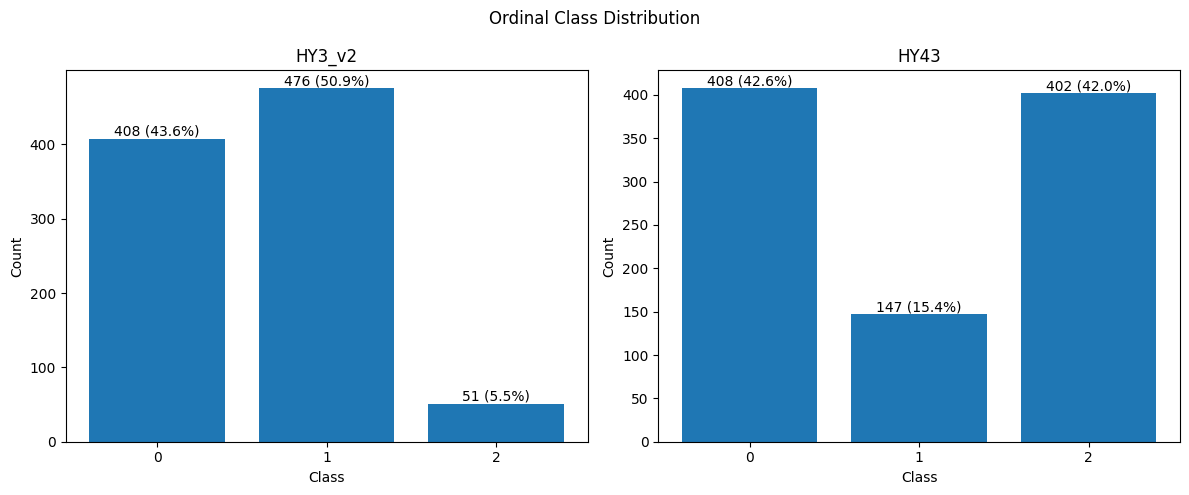

In [31]:
import pandas as pd
import json
import numpy as np
from pathlib import Path

current_dir = Path.cwd()
project_root = current_dir.parents[3]

import matplotlib.pyplot as plt


y_HY3_v2 = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/V2_version/y_HY3_v2_final.csv", index_col=0)
y_HY43 = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/V2_version/y_HY43_v2_final.csv", index_col=0)
print("y_HY3 shape:", y_HY3_v2.shape)
print("y_HY43 shape:", y_HY43.shape)


datasets = {
    "HY3_v2": y_HY3_v2,
    'HY43': y_HY43  # Asegúrate de tener este dataset definido
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, df) in zip(axes, datasets.items()):
    
    counts = df.iloc[:,0].value_counts().sort_index()
    percentages = counts / counts.sum() * 100
    
    bars = ax.bar(counts.index.astype(str), counts.values)
    
    # añadir texto con conteo y porcentaje
    for i, (count, pct) in enumerate(zip(counts.values, percentages.values)):
        ax.text(i, count, f"{count} ({pct:.1f}%)", 
                ha='center', va='bottom')
    
    ax.set_title(name)
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")

plt.suptitle("Ordinal Class Distribution")
plt.tight_layout()
plt.show()

In [32]:
import os
import re

with open(project_root/"SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/Domain_data.json", "r") as archivo:
    full_domain = json.load(archivo)

with open(project_root/"SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/UPDRS_Domain_data.json", "r") as archivo:
    updrs_domain = json.load(archivo)

X_multiples_HY3= {'X_STATS_V2':project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/V2_version/X_stats_v2_final_HY3.csv',
                'X_VX_STATS_V2': project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/V2_version/X_vx_stats_v2_final_HY3.csv',
                'X_VX_DELTA_V2': project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/V2_version/X_vx_delta_v2_final_HY3.csv'}

y_multiples_HY3 = { 'HY3_v2': project_root / "SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/V2_version/y_HY3_v2_final.csv",
                'HY3_v2_sampled': project_root / "SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/V2_version/y_HY3_v2_Sampled_HY3.csv",
                }

X_multiples_HY43= {'X_STATS_V2':project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/V2_version/X_stats_v2_final_HY43.csv',
                        'X_VX_STATS_V2': project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/V2_version/X_vx_stats_v2_final_HY43.csv',
                        'X_VX_DELTA_V2': project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/V2_version/X_vx_delta_v2_final_HY43.csv', }

y_multiples_HY43 = { 'HY43_v2': project_root / "SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/V2_version/y_HY43_v2_final.csv"}


pairs_init_HY3=[('X_STATS_V2', 'HY3_v2'),
        ('X_VX_STATS_V2', 'HY3_v2'),
        ('X_VX_DELTA_V2', 'HY3_v2')]

pairs_init_HY43=[('X_STATS_V2', 'HY43_v2'),
        ('X_VX_STATS_V2', 'HY43_v2'),
        ('X_VX_DELTA_V2', 'HY43_v2')]


output_path= project_root / "SCRIPTS/PYTHON/MODEL_ANALYSIS/Performance_Results/Multiclass/V2_analysis/"

In [33]:
for val1,val2 in pairs_init_HY3:
    print(f"Evaluating pair: {val1} and {val2}")
    X=pd.read_csv(X_multiples_HY3[val1],index_col=0)
    print(f"Shape of X: {X.shape}")

Evaluating pair: X_STATS_V2 and HY3_v2
Shape of X: (935, 301)
Evaluating pair: X_VX_STATS_V2 and HY3_v2
Shape of X: (935, 360)
Evaluating pair: X_VX_DELTA_V2 and HY3_v2
Shape of X: (935, 242)


# HY3

Distribución original:
STAGE_HY3
0    408
1    476
2     51
Name: count, dtype: int64

Bloque reservado para modelo multiclase:
STAGE_HY3
0    51
1    51
2    51
Name: count, dtype: int64

Bloque para modelo binario (solo 0 y 1 restantes):
STAGE_HY3
0    357
1    425
Name: count, dtype: int64

Distribución modelo multiclase:
Train: {0: 30, 1: 30, 2: 30}
Val  : {0: 6, 1: 6, 2: 5}
Test : {0: 15, 1: 15, 2: 16}

Entrenando modelo binario 0 vs 1
[001] train_loss=0.5689 | val_loss=0.3780 | val_acc=0.9108 | val_f1=0.9125
[010] train_loss=0.0094 | val_loss=0.3377 | val_acc=0.8917 | val_f1=0.9017
Early stopping en epoch 18

Resultados validación modelo binario:
Loss: 0.2150
Acc : 0.9236
F1  : 0.9286

Entrenando modelo multiclase - fase 1 (head)
[001] train_loss=1.3202 | val_loss=1.0752 | val_acc=0.7059 | val_f1_macro=0.5686 | val_recall_2=0.0000
[010] train_loss=0.8117 | val_loss=0.6947 | val_acc=0.6471 | val_f1_macro=0.5417 | val_recall_2=1.0000
[020] train_loss=0.7304 | val_loss=0.6257 | val_

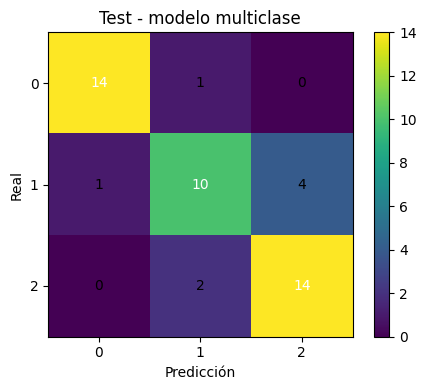


Pipeline completado y guardado.


In [34]:
# =========================================================
# PIPELINE COMPLETO EN PYTORCH
# 1) Reservar 51 de clase 0, 51 de clase 1 y 51 de clase 2
# 2) Entrenar modelo binario SOLO con clases 0 y 1 restantes
# 3) Transferir pesos a un modelo multiclase
# 4) Entrenar modelo multiclase con el bloque reservado
# 5) Evaluar con métricas y matriz de confusión
# =========================================================

import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    classification_report,
    confusion_matrix,
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# =========================
# CONFIG
# =========================
SEED = 42
TARGET_COL = "STAGE_HY3"
BATCH_SIZE = 16
HIDDEN_DIMS = (64,32)
DROPOUT = 0.10

# Entrenamiento modelo binario
BIN_LR = 1e-3
BIN_EPOCHS = 100
BIN_PATIENCE = 15

# Entrenamiento modelo multiclase - fase 1 (solo cabeza)
HEAD_LR = 1e-3
HEAD_EPOCHS = 40
HEAD_PATIENCE = 10

# Entrenamiento modelo multiclase - fase 2 (fine-tuning completo)
FT_LR = 3e-4
FT_EPOCHS = 80
FT_PATIENCE = 15

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# =========================
# UTILIDADES
# =========================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

def make_loader(X, y, batch_size=32, shuffle=False, task="multiclass"):
    X_t = torch.tensor(X, dtype=torch.float32)
    if task == "binary":
        y_t = torch.tensor(y, dtype=torch.float32)
    else:
        y_t = torch.tensor(y, dtype=torch.long)
    ds = TensorDataset(X_t, y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

class TabularMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=(64, 32), dropout=0.2, num_classes=1):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.head = nn.Linear(hidden_dims[1], num_classes)

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.head(x)
        return x

def set_feature_extractor_trainable(model, trainable=True):
    for p in model.feature_extractor.parameters():
        p.requires_grad = trainable

@torch.no_grad()
def evaluate(model, loader, criterion, task="binary"):
    model.eval()

    total_loss = 0.0
    n_samples = 0

    y_true_all = []
    y_pred_all = []

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        logits = model(xb)

        if task == "binary":
            logits = logits.squeeze(1)
            loss = criterion(logits, yb)
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).long()
            y_true_all.extend(yb.cpu().numpy().astype(int))
            y_pred_all.extend(preds.cpu().numpy().astype(int))
        else:
            loss = criterion(logits, yb)
            preds = torch.argmax(logits, dim=1)
            y_true_all.extend(yb.cpu().numpy())
            y_pred_all.extend(preds.cpu().numpy())

        total_loss += loss.item() * xb.size(0)
        n_samples += xb.size(0)

    avg_loss = total_loss / n_samples
    acc = accuracy_score(y_true_all, y_pred_all)

    if task == "binary":
        f1 = f1_score(y_true_all, y_pred_all, average="binary", zero_division=0)
        metrics = {
            "loss": avg_loss,
            "acc": acc,
            "f1": f1,
            "y_true": np.array(y_true_all),
            "y_pred": np.array(y_pred_all),
        }
    else:
        f1_macro = f1_score(y_true_all, y_pred_all, average="macro", zero_division=0)
        recalls = recall_score(y_true_all, y_pred_all, average=None, labels=[0, 1, 2], zero_division=0)
        metrics = {
            "loss": avg_loss,
            "acc": acc,
            "f1_macro": f1_macro,
            "recall_0": recalls[0],
            "recall_1": recalls[1],
            "recall_2": recalls[2],
            "y_true": np.array(y_true_all),
            "y_pred": np.array(y_pred_all),
        }

    return metrics

def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    task="binary",
    epochs=100,
    patience=15,
    verbose=True,
):
    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")
    wait = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        n_samples = 0

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)

            if task == "binary":
                logits = logits.squeeze(1)
                loss = criterion(logits, yb)
            else:
                loss = criterion(logits, yb)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)
            n_samples += xb.size(0)

        train_loss = running_loss / n_samples
        val_metrics = evaluate(model, val_loader, criterion, task=task)

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_metrics["loss"],
        }

        if task == "binary":
            row["val_acc"] = val_metrics["acc"]
            row["val_f1"] = val_metrics["f1"]
        else:
            row["val_acc"] = val_metrics["acc"]
            row["val_f1_macro"] = val_metrics["f1_macro"]
            row["val_recall_2"] = val_metrics["recall_2"]

        history.append(row)

        if verbose and (epoch == 1 or epoch % 10 == 0):
            if task == "binary":
                print(
                    f"[{epoch:03d}] "
                    f"train_loss={train_loss:.4f} | "
                    f"val_loss={val_metrics['loss']:.4f} | "
                    f"val_acc={val_metrics['acc']:.4f} | "
                    f"val_f1={val_metrics['f1']:.4f}"
                )
            else:
                print(
                    f"[{epoch:03d}] "
                    f"train_loss={train_loss:.4f} | "
                    f"val_loss={val_metrics['loss']:.4f} | "
                    f"val_acc={val_metrics['acc']:.4f} | "
                    f"val_f1_macro={val_metrics['f1_macro']:.4f} | "
                    f"val_recall_2={val_metrics['recall_2']:.4f}"
                )

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                if verbose:
                    print(f"Early stopping en epoch {epoch}")
                break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

def plot_confusion_matrix(cm, class_names=("0", "1", "2"), title="Matriz de confusión"):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, interpolation="nearest")
    plt.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        xlabel="Predicción",
        ylabel="Real",
        title=title,
    )

    thresh = cm.max() / 2 if cm.max() > 0 else 0.5
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, str(cm[i, j]),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black"
            )
    plt.tight_layout()
    plt.show()


# =========================================================
# 0) CARGA DE DATOS
# =========================================================
# EJEMPLO:
X=pd.read_csv(X_multiples_HY3['X_VX_DELTA_V2'],index_col=0)
y=pd.read_csv(y_multiples_HY3['HY3_v2'],index_col=0)
df = pd.concat([X, y], axis=1)
df.reset_index(drop=True, inplace=True)



feature_cols = [c for c in df.columns if c != TARGET_COL]

# Comprobaciones básicas
assert TARGET_COL in df.columns, f"No existe la columna objetivo '{TARGET_COL}'"
assert set(df[TARGET_COL].unique()).issubset({0, 1, 2}), "Las clases deben ser 0, 1 y 2"

print("Distribución original:")
print(df[TARGET_COL].value_counts().sort_index())

assert (df[TARGET_COL] == 0).sum() >= 51, "No hay al menos 51 muestras de clase 0"
assert (df[TARGET_COL] == 1).sum() >= 51, "No hay al menos 51 muestras de clase 1"
assert (df[TARGET_COL] == 2).sum() >= 51, "No hay al menos 51 muestras de clase 2"

# =========================================================
# 1) RESERVAR 51 DE CADA CLASE PARA EL MODELO MULTICLASE
# =========================================================
idx0 = df[df[TARGET_COL] == 0].sample(n=51, random_state=SEED).index
idx1 = df[df[TARGET_COL] == 1].sample(n=51, random_state=SEED).index
idx2 = df[df[TARGET_COL] == 2].sample(n=51, random_state=SEED).index

reserved_idx = np.concatenate([idx0.to_numpy(), idx1.to_numpy(), idx2.to_numpy()])

reserved_df = df.loc[reserved_idx].copy()
binary_df = df.loc[(~df.index.isin(reserved_idx)) & (df[TARGET_COL].isin([0, 1]))].copy()

print("\nBloque reservado para modelo multiclase:")
print(reserved_df[TARGET_COL].value_counts().sort_index())

print("\nBloque para modelo binario (solo 0 y 1 restantes):")
print(binary_df[TARGET_COL].value_counts().sort_index())

# =========================================================
# 2) SPLITS
# =========================================================
# ---- Modelo binario: split train/val para early stopping
X_bin = binary_df[feature_cols].astype(np.float32).values
y_bin = binary_df[TARGET_COL].astype(np.float32).values  # 0 o 1

Xb_train, Xb_val, yb_train, yb_val = train_test_split(
    X_bin, y_bin,
    test_size=0.20,
    stratify=y_bin,
    random_state=SEED
)

# ---- Modelo multiclase: 70% train / 30% test
X_res = reserved_df[feature_cols].astype(np.float32).values
y_res = reserved_df[TARGET_COL].astype(np.int64).values  # 0,1,2

X2_train_full, X2_test, y2_train_full, y2_test = train_test_split(
    X_res, y_res,
    test_size=0.30,
    stratify=y_res,
    random_state=SEED
)

# Del 70% train, sacamos una pequeña validación interna
X2_train, X2_val, y2_train, y2_val = train_test_split(
    X2_train_full, y2_train_full,
    test_size=0.15,
    stratify=y2_train_full,
    random_state=SEED
)

print("\nDistribución modelo multiclase:")
print("Train:", pd.Series(y2_train).value_counts().sort_index().to_dict())
print("Val  :", pd.Series(y2_val).value_counts().sort_index().to_dict())
print("Test :", pd.Series(y2_test).value_counts().sort_index().to_dict())

# =========================================================
# 3) ESCALADO
# =========================================================
# IMPORTANTE:
# Para que la transferencia tenga sentido, usamos el MISMO scaler
# ajustado con el train del modelo binario.
scaler = StandardScaler()

Xb_train = scaler.fit_transform(Xb_train)
Xb_val   = scaler.transform(Xb_val)

X2_train = scaler.transform(X2_train)
X2_val   = scaler.transform(X2_val)
X2_test  = scaler.transform(X2_test)

# =========================================================
# 4) DATALOADERS
# =========================================================
bin_train_loader = make_loader(Xb_train, yb_train, batch_size=BATCH_SIZE, shuffle=True, task="binary")
bin_val_loader   = make_loader(Xb_val,   yb_val,   batch_size=BATCH_SIZE, shuffle=False, task="binary")

mc_train_loader = make_loader(X2_train, y2_train, batch_size=BATCH_SIZE, shuffle=True, task="multiclass")
mc_val_loader   = make_loader(X2_val,   y2_val,   batch_size=BATCH_SIZE, shuffle=False, task="multiclass")
mc_test_loader  = make_loader(X2_test,  y2_test,  batch_size=BATCH_SIZE, shuffle=False, task="multiclass")

# =========================================================
# 5) MODELO 1: BINARIO (0 vs 1)
# =========================================================
input_dim = Xb_train.shape[1]

binary_model = TabularMLP(
    input_dim=input_dim,
    hidden_dims=HIDDEN_DIMS,
    dropout=DROPOUT,
    num_classes=1
).to(DEVICE)

criterion_bin = nn.BCEWithLogitsLoss()
optimizer_bin = torch.optim.Adam(
    binary_model.parameters(),
    lr=BIN_LR,
    weight_decay=1e-4
)

print("\n==============================")
print("Entrenando modelo binario 0 vs 1")
print("==============================")

binary_model, hist_bin = train_model(
    model=binary_model,
    train_loader=bin_train_loader,
    val_loader=bin_val_loader,
    criterion=criterion_bin,
    optimizer=optimizer_bin,
    task="binary",
    epochs=BIN_EPOCHS,
    patience=BIN_PATIENCE,
    verbose=True,
)

bin_val_metrics = evaluate(binary_model, bin_val_loader, criterion_bin, task="binary")

print("\nResultados validación modelo binario:")
print(f"Loss: {bin_val_metrics['loss']:.4f}")
print(f"Acc : {bin_val_metrics['acc']:.4f}")
print(f"F1  : {bin_val_metrics['f1']:.4f}")

# Guardar extractor de características si quieres reutilizarlo luego
torch.save(binary_model.feature_extractor.state_dict(), "feature_extractor_binario_0_1.pt")

# =========================================================
# 6) MODELO 2: MULTICLASE CON TRANSFER LEARNING
# =========================================================
multiclass_model = TabularMLP(
    input_dim=input_dim,
    hidden_dims=HIDDEN_DIMS,
    dropout=DROPOUT,
    num_classes=3
).to(DEVICE)

# Cargar pesos del extractor aprendido en el binario
multiclass_model.feature_extractor.load_state_dict(
    binary_model.feature_extractor.state_dict()
)

weights = torch.tensor([1.0, 2, 1.0], dtype=torch.float32).to(DEVICE)
criterion_mc = nn.CrossEntropyLoss(weight=weights)
# -------------------------
# FASE 1: congelar extractor y entrenar solo la cabeza
# -------------------------
set_feature_extractor_trainable(multiclass_model, trainable=False)

optimizer_head = torch.optim.Adam(
    filter(lambda p: p.requires_grad, multiclass_model.parameters()),
    lr=HEAD_LR,
    weight_decay=1e-4
)

print("\n==============================================")
print("Entrenando modelo multiclase - fase 1 (head)")
print("==============================================")

multiclass_model, hist_head = train_model(
    model=multiclass_model,
    train_loader=mc_train_loader,
    val_loader=mc_val_loader,
    criterion=criterion_mc,
    optimizer=optimizer_head,
    task="multiclass",
    epochs=HEAD_EPOCHS,
    patience=HEAD_PATIENCE,
    verbose=True,
)

# -------------------------
# FASE 2: descongelar todo y fine-tuning
# -------------------------
set_feature_extractor_trainable(multiclass_model, trainable=True)

optimizer_ft = torch.optim.Adam(
    multiclass_model.parameters(),
    lr=FT_LR,
    weight_decay=1e-4
)

print("\n==================================================")
print("Entrenando modelo multiclase - fase 2 (fine-tuning)")
print("==================================================")

multiclass_model, hist_ft = train_model(
    model=multiclass_model,
    train_loader=mc_train_loader,
    val_loader=mc_val_loader,
    criterion=criterion_mc,
    optimizer=optimizer_ft,
    task="multiclass",
    epochs=FT_EPOCHS,
    patience=FT_PATIENCE,
    verbose=True,
)

# =========================================================
# 7) EVALUACIÓN FINAL EN TEST DEL MODELO MULTICLASE
# =========================================================
test_metrics = evaluate(multiclass_model, mc_test_loader, criterion_mc, task="multiclass")

print("\n==============================")
print("TEST FINAL MODELO MULTICLASE")
print("==============================")
print(f"Loss           : {test_metrics['loss']:.4f}")
print(f"Accuracy       : {test_metrics['acc']:.4f}")
print(f"F1 macro       : {test_metrics['f1_macro']:.4f}")
print(f"Recall clase 0 : {test_metrics['recall_0']:.4f}")
print(f"Recall clase 1 : {test_metrics['recall_1']:.4f}")
print(f"Recall clase 2 : {test_metrics['recall_2']:.4f}")

y_true = test_metrics["y_true"]
y_pred = test_metrics["y_pred"]

print("\nClassification report:")
print(classification_report(y_true, y_pred, digits=4, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
print("Matriz de confusión:")
print(cm)

plot_confusion_matrix(cm, class_names=("0", "1", "2"), title="Test - modelo multiclase")

# =========================================================
# 8) GUARDAR MODELO FINAL
# =========================================================
torch.save({
    "scaler_mean": scaler.mean_,
    "scaler_scale": scaler.scale_,
    "feature_cols": feature_cols,
    "binary_feature_extractor_state_dict": binary_model.feature_extractor.state_dict(),
    "multiclass_model_state_dict": multiclass_model.state_dict(),
}, "pipeline_transfer_tabular_pytorch.pt")

print("\nPipeline completado y guardado.")

---


Distribución global modelo multiclase (bloque reservado):
{0: 51, 1: 51, 2: 51}

Entrenando modelo binario 0 vs 1
[001] train_loss=0.5590 | val_loss=0.3703 | val_acc=0.8917 | val_f1=0.8970
[010] train_loss=0.0143 | val_loss=0.3565 | val_acc=0.8917 | val_f1=0.9006
Early stopping en epoch 18

Resultados validación modelo binario:
Loss: 0.2158
Acc : 0.9236
F1  : 0.9277

FOLD 1/10
Distribución fold:
Train: {0: 36, 1: 36, 2: 37}
Val  : {0: 9, 1: 10, 2: 9}
Test : {0: 6, 1: 5, 2: 5}

Resultados fold 1:
Loss           : 0.3374
Accuracy       : 0.9375
F1 macro       : 0.9327
Recall clase 0 : 1.0000
Recall clase 1 : 1.0000
Recall clase 2 : 0.8000
Matriz de confusión del fold:
[[6 0 0]
 [0 5 0]
 [0 1 4]]

FOLD 2/10
Distribución fold:
Train: {0: 36, 1: 36, 2: 37}
Val  : {0: 10, 1: 9, 2: 9}
Test : {0: 5, 1: 6, 2: 5}

Resultados fold 2:
Loss           : 0.4310
Accuracy       : 0.8750
F1 macro       : 0.8778
Recall clase 0 : 1.0000
Recall clase 1 : 0.6667
Recall clase 2 : 1.0000
Matriz de confusión 

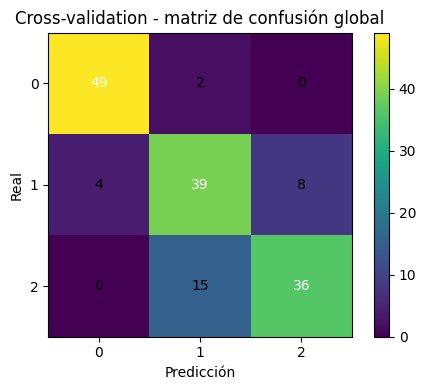


Cross-validation completado y resultados guardados.


In [40]:
# =========================================================
# 2) SPLITS + CROSS-VALIDATION MULTICLASE
# =========================================================
from sklearn.model_selection import StratifiedKFold

N_SPLITS = 10

# ---- Modelo binario: split train/val para early stopping
X_bin = binary_df[feature_cols].astype(np.float32).values
y_bin = binary_df[TARGET_COL].astype(np.float32).values  # 0 o 1

Xb_train, Xb_val, yb_train, yb_val = train_test_split(
    X_bin, y_bin,
    test_size=0.20,
    stratify=y_bin,
    random_state=SEED
)

# ---- Datos del bloque reservado para CV multiclase
X_res = reserved_df[feature_cols].astype(np.float32).values
y_res = reserved_df[TARGET_COL].astype(np.int64).values  # 0,1,2

print("\nDistribución global modelo multiclase (bloque reservado):")
print(pd.Series(y_res).value_counts().sort_index().to_dict())

# =========================================================
# 3) ESCALADO
# =========================================================
# IMPORTANTE:
# mantenemos tu lógica: el scaler se ajusta SOLO con el train binario
scaler = StandardScaler()

Xb_train = scaler.fit_transform(Xb_train)
Xb_val   = scaler.transform(Xb_val)

# =========================================================
# 4) DATALOADERS BINARIOS
# =========================================================
bin_train_loader = make_loader(Xb_train, yb_train, batch_size=BATCH_SIZE, shuffle=True, task="binary")
bin_val_loader   = make_loader(Xb_val,   yb_val,   batch_size=BATCH_SIZE, shuffle=False, task="binary")

# =========================================================
# 5) MODELO 1: BINARIO (0 vs 1)
# =========================================================
input_dim = Xb_train.shape[1]

binary_model = TabularMLP(
    input_dim=input_dim,
    hidden_dims=HIDDEN_DIMS,
    dropout=DROPOUT,
    num_classes=1
).to(DEVICE)

criterion_bin = nn.BCEWithLogitsLoss()
optimizer_bin = torch.optim.Adam(
    binary_model.parameters(),
    lr=BIN_LR,
    weight_decay=1e-4
)

print("\n==============================")
print("Entrenando modelo binario 0 vs 1")
print("==============================")

binary_model, hist_bin = train_model(
    model=binary_model,
    train_loader=bin_train_loader,
    val_loader=bin_val_loader,
    criterion=criterion_bin,
    optimizer=optimizer_bin,
    task="binary",
    epochs=BIN_EPOCHS,
    patience=BIN_PATIENCE,
    verbose=True,
)

bin_val_metrics = evaluate(binary_model, bin_val_loader, criterion_bin, task="binary")

print("\nResultados validación modelo binario:")
print(f"Loss: {bin_val_metrics['loss']:.4f}")
print(f"Acc : {bin_val_metrics['acc']:.4f}")
print(f"F1  : {bin_val_metrics['f1']:.4f}")

# Guardar extractor de características si quieres reutilizarlo luego
torch.save(binary_model.feature_extractor.state_dict(), "feature_extractor_binario_0_1.pt")

# =========================================================
# 6) CROSS-VALIDATION DEL MODELO MULTICLASE
# =========================================================
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

cv_results = []
all_y_true = []
all_y_pred = []
fold_confusions = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_res, y_res), start=1):
    print("\n" + "=" * 60)
    print(f"FOLD {fold}/{N_SPLITS}")
    print("=" * 60)

    # reproducibilidad por fold
    set_seed(SEED + fold)

    # ---------------------------------
    # split externo del fold: train/test
    # ---------------------------------
    X_fold_train_full = X_res[train_idx]
    y_fold_train_full = y_res[train_idx]

    X_fold_test = X_res[test_idx]
    y_fold_test = y_res[test_idx]

    # ---------------------------------
    # split interno: train/val para early stopping
    # ---------------------------------
    X_fold_train, X_fold_val, y_fold_train, y_fold_val = train_test_split(
        X_fold_train_full,
        y_fold_train_full,
        test_size=0.20,
        stratify=y_fold_train_full,
        random_state=SEED
    )

    print("Distribución fold:")
    print("Train:", pd.Series(y_fold_train).value_counts().sort_index().to_dict())
    print("Val  :", pd.Series(y_fold_val).value_counts().sort_index().to_dict())
    print("Test :", pd.Series(y_fold_test).value_counts().sort_index().to_dict())

    # ---------------------------------
    # usar el MISMO scaler del binario
    # ---------------------------------
    X_fold_train = scaler.transform(X_fold_train)
    X_fold_val   = scaler.transform(X_fold_val)
    X_fold_test  = scaler.transform(X_fold_test)

    # ---------------------------------
    # dataloaders multiclase
    # ---------------------------------
    mc_train_loader = make_loader(
        X_fold_train, y_fold_train,
        batch_size=BATCH_SIZE, shuffle=True, task="multiclass"
    )
    mc_val_loader = make_loader(
        X_fold_val, y_fold_val,
        batch_size=BATCH_SIZE, shuffle=False, task="multiclass"
    )
    mc_test_loader = make_loader(
        X_fold_test, y_fold_test,
        batch_size=BATCH_SIZE, shuffle=False, task="multiclass"
    )

    # ---------------------------------
    # modelo multiclase nuevo para este fold
    # ---------------------------------
    multiclass_model = TabularMLP(
        input_dim=input_dim,
        hidden_dims=HIDDEN_DIMS,
        dropout=DROPOUT,
        num_classes=3
    ).to(DEVICE)

    # cargar pesos del extractor binario
    multiclass_model.feature_extractor.load_state_dict(
        binary_model.feature_extractor.state_dict()
    )

    # pesos de clase (mantengo tu mejora para la clase 1)
    weights = torch.tensor([1.0, 2.5, 1.0], dtype=torch.float32).to(DEVICE)
    criterion_mc = nn.CrossEntropyLoss(weight=weights)

    # -------------------------
    # FASE 1: congelar extractor y entrenar solo la cabeza
    # -------------------------
    set_feature_extractor_trainable(multiclass_model, trainable=False)

    optimizer_head = torch.optim.Adam(
        filter(lambda p: p.requires_grad, multiclass_model.parameters()),
        lr=HEAD_LR,
        weight_decay=1e-4
    )

    multiclass_model, hist_head = train_model(
        model=multiclass_model,
        train_loader=mc_train_loader,
        val_loader=mc_val_loader,
        criterion=criterion_mc,
        optimizer=optimizer_head,
        task="multiclass",
        epochs=HEAD_EPOCHS,
        patience=HEAD_PATIENCE,
        verbose=False,
    )

    # -------------------------
    # FASE 2: descongelar todo y fine-tuning
    # -------------------------
    set_feature_extractor_trainable(multiclass_model, trainable=True)

    optimizer_ft = torch.optim.Adam(
        multiclass_model.parameters(),
        lr=FT_LR,
        weight_decay=1e-4
    )

    multiclass_model, hist_ft = train_model(
        model=multiclass_model,
        train_loader=mc_train_loader,
        val_loader=mc_val_loader,
        criterion=criterion_mc,
        optimizer=optimizer_ft,
        task="multiclass",
        epochs=FT_EPOCHS,
        patience=FT_PATIENCE,
        verbose=False,
    )

    # -------------------------
    # evaluación del fold
    # -------------------------
    fold_metrics = evaluate(multiclass_model, mc_test_loader, criterion_mc, task="multiclass")

    print(f"\nResultados fold {fold}:")
    print(f"Loss           : {fold_metrics['loss']:.4f}")
    print(f"Accuracy       : {fold_metrics['acc']:.4f}")
    print(f"F1 macro       : {fold_metrics['f1_macro']:.4f}")
    print(f"Recall clase 0 : {fold_metrics['recall_0']:.4f}")
    print(f"Recall clase 1 : {fold_metrics['recall_1']:.4f}")
    print(f"Recall clase 2 : {fold_metrics['recall_2']:.4f}")

    y_true_fold = fold_metrics["y_true"]
    y_pred_fold = fold_metrics["y_pred"]

    cm_fold = confusion_matrix(y_true_fold, y_pred_fold, labels=[0, 1, 2])
    print("Matriz de confusión del fold:")
    print(cm_fold)

    cv_results.append({
        "fold": fold,
        "loss": fold_metrics["loss"],
        "acc": fold_metrics["acc"],
        "f1_macro": fold_metrics["f1_macro"],
        "recall_0": fold_metrics["recall_0"],
        "recall_1": fold_metrics["recall_1"],
        "recall_2": fold_metrics["recall_2"],
    })

    all_y_true.extend(y_true_fold.tolist())
    all_y_pred.extend(y_pred_fold.tolist())
    fold_confusions.append(cm_fold)

# =========================================================
# 7) RESUMEN FINAL DE CROSS-VALIDATION
# =========================================================
cv_results_df = pd.DataFrame(cv_results)

print("\n==============================")
print("RESULTADOS CROSS-VALIDATION")
print("==============================")
print(cv_results_df)

print("\nPromedio de métricas:")
print(cv_results_df[["loss", "acc", "f1_macro", "recall_0", "recall_1", "recall_2"]].mean())

print("\nDesviación estándar:")
print(cv_results_df[["loss", "acc", "f1_macro", "recall_0", "recall_1", "recall_2"]].std())

print("\nClassification report global (todos los folds juntos):")
print(classification_report(all_y_true, all_y_pred, digits=4, zero_division=0))

cm_global = confusion_matrix(all_y_true, all_y_pred, labels=[0, 1, 2])
print("Matriz de confusión global:")
print(cm_global)

plot_confusion_matrix(
    cm_global,
    class_names=("0", "1", "2"),
    title="Cross-validation - matriz de confusión global"
)

# =========================================================
# 8) GUARDAR RESULTADOS CV
# =========================================================
cv_results_df.to_csv("cv_results_multiclass_transfer.csv", index=False)

torch.save({
    "scaler_mean": scaler.mean_,
    "scaler_scale": scaler.scale_,
    "feature_cols": feature_cols,
    "binary_feature_extractor_state_dict": binary_model.feature_extractor.state_dict(),
    "cv_results": cv_results,
    "global_confusion_matrix": cm_global,
}, "pipeline_transfer_tabular_cv_results.pt")

print("\nCross-validation completado y resultados guardados.")